Model Preparation for LightGBM Regression


Model Preparation for LightGBM Regression


In [2]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error


agg_full = pd.read_csv("agg_full_with_tsfresh.csv", parse_dates=['order_date'])
model = agg_full.sort_values(['coating_id', 'order_date'])
model['target_total_fill_rate_next_day'] = model.groupby('coating_id')['total_fill_rate'].shift(-1)

next_day_features= [
    # calendar parts
    "day", "weekday", "week_of_year", "month", "quarter", "year",
    "day_sin", "day_cos",
    "weekday_sin", "weekday_cos",
    "month_sin", "month_cos", "month_progression",
    "quarter_sin", "quarter_cos", "quarter_progression",
    "year_progression",

    # business-day flags
    "is_first_business_day_of_month", "is_last_business_day_of_month",
    "is_first_business_day_of_quarter", "is_last_business_day_of_quarter",
    "is_first_business_day_of_year",  "is_last_business_day_of_year",

    # holiday logic
    "is_holiday", "day_before_holiday", "week_before_holiday",
    "bridgeday_flag", "holiday_week_including_weekends",
    "holiday_week_excluding_weekends",
]


for col in next_day_features:
    model[col + '_next_day'] = model.groupby('coating_id')[col].shift(-1)

# 3. Filter out last day for each coating_id (target will be nan there)
agg_full_model = model.dropna(subset=['target_total_fill_rate_next_day'])

# 4. Prepare feature columns (exclude leakage: don't use 'total_fill_rate' itself!)
exclude_cols = [
    'order_date', 'target_total_fill_rate_next_day',
]
feature_cols = [c for c in agg_full_model.columns if c not in exclude_cols]

# 5. Split into train/test (e.g., last 20% of dates is test)
split_date = agg_full_model['order_date'].quantile(0.8)
train = agg_full_model[agg_full_model['order_date'] <= split_date]
test  = agg_full_model[agg_full_model['order_date'] > split_date]

X_train = train[feature_cols]
y_train = train['target_total_fill_rate_next_day']
X_test  = test[feature_cols]
y_test  = test['target_total_fill_rate_next_day']

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# One-hot encode
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns (important for missing categories in test/train)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)



# 1. Dataset für LightGBM
lgb_train = lgb.Dataset(X_train, y_train)
lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

# 2. Parameter (einfaches Regressionsmodell)
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5
}

# 3. Training
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test]
)

# 4. Vorhersagen & Bewertung
y_pred = model.predict(X_test, num_iteration=model.best_iteration)
rmse = mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")

RMSE: 27.3594
MAE: 2.3949
R²: 0.4878


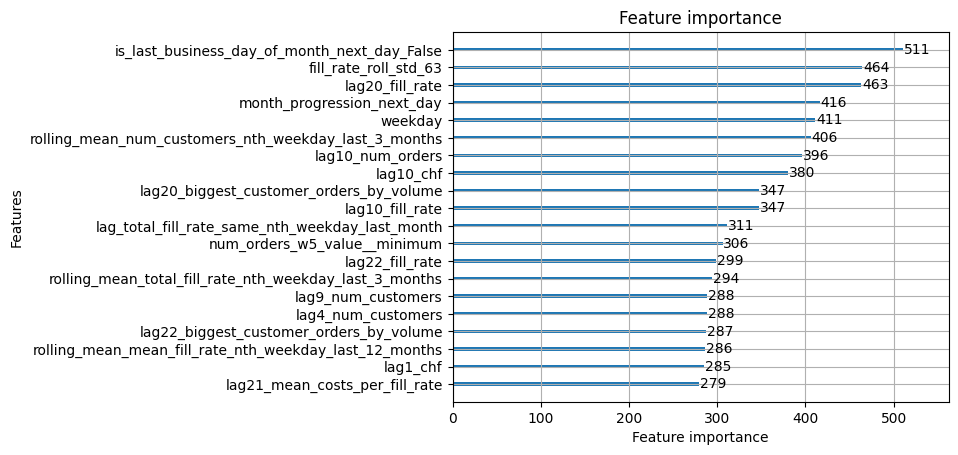

In [3]:
import matplotlib.pyplot as plt

lgb.plot_importance(model, max_num_features=20)
plt.show()

Top 20 most important features for predicting next day's fill rate:
                                               feature  importance
          is_last_business_day_of_month_next_day_False         511
                                 fill_rate_roll_std_63         464
                                       lag20_fill_rate         463
                            month_progression_next_day         416
                                               weekday         411
  rolling_mean_num_customers_nth_weekday_last_3_months         406
                                      lag10_num_orders         396
                                             lag10_chf         380
               lag20_biggest_customer_orders_by_volume         347
                                       lag10_fill_rate         347
       lag_total_fill_rate_same_nth_weekday_last_month         311
                          num_orders_w5_value__minimum         306
                                       lag22_fill_rate       

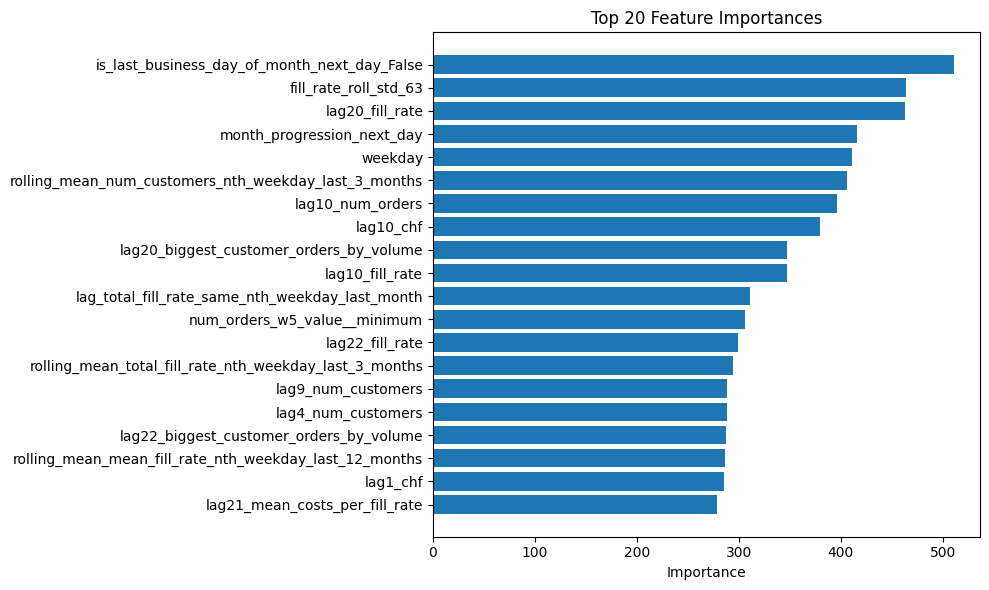

In [4]:
importances = model.feature_importance()
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,  # Use the columns after encoding!
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Show top 20 most important features
print("Top 20 most important features for predicting next day's fill rate:")
print(feature_importance_df.head(20).to_string(index=False))

# Optionally, plot feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_n = 20
plt.barh(feature_importance_df['feature'].head(top_n)[::-1], feature_importance_df['importance'].head(top_n)[::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

Permutation

from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import copy

def permutation_importance(model, X_valid, y_valid, metric=mean_squared_error, n_repeats=5):
    baseline_pred = model.predict(X_valid, num_iteration=model.best_iteration)
    baseline_score = metric(y_valid, baseline_pred)
    
    importances = []

    for col in X_valid.columns:
        scores = []
        for _ in range(n_repeats):
            X_permuted = X_valid.copy()
            X_permuted[col] = np.random.permutation(X_permuted[col].values)
            permuted_pred = model.predict(X_permuted, num_iteration=model.best_iteration)
            score = metric(y_valid, permuted_pred)
            scores.append(score)
        avg_score = np.mean(scores)
        importance = avg_score - baseline_score  # Positive means feature is useful, negative may hurt
        importances.append((col, importance))

    # Sort descending by importance
    importance_df = pd.DataFrame(importances, columns=['feature', 'importance_diff'])
    importance_df.sort_values(by='importance_diff', ascending=False, inplace=True)
    
    return importance_df

# Example usage on your main test set:
perm_importance_df = permutation_importance(model, X_test, y_test)
print("Permutation Importances (Positive means useful, Negative may hurt):")
print(perm_importance_df.head(20))

# Optional: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_n = 20
plt.barh(perm_importance_df['feature'].head(top_n)[::-1], perm_importance_df['importance_diff'].head(top_n)[::-1])
plt.xlabel('Change in RMSE (Permuted - Baseline)')
plt.title('Top 20 Permutation Importances')
plt.tight_layout()
plt.show()


Represent all metrics per coating id



In [5]:
from sklearn.metrics import r2_score

# Testdaten um Vorhersagen ergänzen
test_copy = test.copy()
test_copy['y_true'] = y_test.values
test_copy['y_pred'] = y_pred

# R²-Werte pro coating_id berechnen
r2_by_coating = []

for coating_id, group in test_copy.groupby('coating_id'):
    y_true = group['y_true']
    y_pred_ = group['y_pred']

    mask = y_true.notna() & y_pred_.notna()
    y_true = y_true[mask]
    y_pred_ = y_pred_[mask]

    if len(y_true) == 0:
        continue

    r2 = r2_score(y_true, y_pred_)
    r2_by_coating.append((coating_id, r2))

# Ergebnis ausgeben (sortiert nach R²)
for coating_id, r2 in sorted(r2_by_coating, key=lambda x: x[1], reverse=True):
    print(f"coating_id: {coating_id}, R²: {r2:.4f}")

coating_id: 68, R²: 0.5516
coating_id: 29, R²: 0.5214
coating_id: 3, R²: 0.4493
coating_id: 12, R²: 0.3734
coating_id: 69, R²: 0.3671
coating_id: 7, R²: 0.3359
coating_id: 23, R²: 0.2893
coating_id: 121, R²: 0.2455
coating_id: 8, R²: 0.2436
coating_id: 52, R²: 0.2246
coating_id: 25, R²: 0.1584
coating_id: 15, R²: 0.1335
coating_id: 33, R²: 0.1126
coating_id: 46, R²: 0.1005
coating_id: 22, R²: 0.0381
coating_id: 59, R²: 0.0358
coating_id: 110, R²: 0.0213
coating_id: 9, R²: -0.0212
coating_id: 40, R²: -0.0342
coating_id: 4, R²: -0.0469
coating_id: 117, R²: -0.0549
coating_id: 6, R²: -0.0820
coating_id: 10, R²: -0.1181
coating_id: 54, R²: -0.1363
coating_id: 5, R²: -0.1584
coating_id: 30, R²: -0.1852
coating_id: 1, R²: -0.2448
coating_id: 2, R²: -0.3740
coating_id: 24, R²: -0.4017
coating_id: 27, R²: -0.4076
coating_id: 16, R²: -0.4617
coating_id: 80, R²: -0.4952
coating_id: 28, R²: -0.5344
coating_id: 21, R²: -0.6316
coating_id: 13, R²: -1.9566
coating_id: 20, R²: -563.7806


In [6]:
# Nur negative R²-Werte ausgeben
print("\nCoating-IDs mit negativem R²:")
counter = 0
for coating_id, r2 in sorted(r2_by_coating, key=lambda x: x[1]):

    if r2 < 0:
        counter += 1
        print(f"coating_id: {coating_id}, R²: {r2:.4f}")

print(f"Amount of coating_ids with negative R²: {counter}")


Coating-IDs mit negativem R²:
coating_id: 20, R²: -563.7806
coating_id: 13, R²: -1.9566
coating_id: 21, R²: -0.6316
coating_id: 28, R²: -0.5344
coating_id: 80, R²: -0.4952
coating_id: 16, R²: -0.4617
coating_id: 27, R²: -0.4076
coating_id: 24, R²: -0.4017
coating_id: 2, R²: -0.3740
coating_id: 1, R²: -0.2448
coating_id: 30, R²: -0.1852
coating_id: 5, R²: -0.1584
coating_id: 54, R²: -0.1363
coating_id: 10, R²: -0.1181
coating_id: 6, R²: -0.0820
coating_id: 117, R²: -0.0549
coating_id: 4, R²: -0.0469
coating_id: 40, R²: -0.0342
coating_id: 9, R²: -0.0212
Amount of coating_ids with negative R²: 19


In [7]:
# Training neuer Modelle für jede coating_id und alle features


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

# Ergebnisse speichern
results = []

# Alle coating_ids durchgehen
for coating_id in agg_full_model['coating_id'].unique():
    df = agg_full_model[agg_full_model['coating_id'] == coating_id]

    # Skip wenn zu wenige Daten vorhanden sind
    if len(df) < 30:
        continue

    # Train/Test Split (zeitbasiert)
    split_date = df['order_date'].quantile(0.8)
    train = df[df['order_date'] <= split_date]
    test = df[df['order_date'] > split_date]

    if train.empty or test.empty:
        continue

    # Features und Target
    X_train = train[feature_cols]
    y_train = train['target_total_fill_rate_next_day']
    X_test  = test[feature_cols]
    y_test  = test['target_total_fill_rate_next_day']

    # One-hot encoding (für Objektspalten)
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
    X_train = pd.get_dummies(X_train, columns=cat_cols)
    X_test = pd.get_dummies(X_test, columns=cat_cols)

    # Align columns
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    # LightGBM Dataset
    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

    # Parameter
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'learning_rate': 0.01,
        'num_leaves': 64
    }

    # Training
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=300,
        valid_sets=[lgb_train]
    )

    # Vorhersage & Metriken
    y_pred = model.predict(X_test)
    mask = ~y_test.isna() & ~pd.isna(y_pred)
    y_test_filtered = y_test[mask]
    y_pred_filtered = y_pred[mask]

    if len(y_test_filtered) == 0:
        continue

    rmse = mean_squared_error(y_test_filtered, y_pred_filtered)
    mae = mean_absolute_error(y_test_filtered, y_pred_filtered)
    r2 = r2_score(y_test_filtered, y_pred_filtered)

    # Ergebnisse speichern
    results.append({
        'coating_id': coating_id,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'num_train_samples': len(train),
        'num_test_samples': len(test),
        # Optional: 'model': model
    })

# Ergebnis als DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='r2', ascending=False))


    coating_id        rmse        mae           r2  num_train_samples  \
30          68   16.173189   2.053692     0.507728                469   
31          69    4.549377   1.100867     0.449717                469   
22          29    7.374133   1.705914     0.441647                469   
10          12  179.410309   6.882810     0.375359                469   
17          23   48.288213   3.846371     0.360141                469   
7            8   15.211819   2.660192     0.253351                469   
24          33    3.153192   1.088702     0.144856                469   
6            7   25.334595   3.298310     0.141978                469   
34         117   30.885714   4.272650     0.075960                469   
26          46    2.904978   1.284809     0.068840                469   
33         110    7.224672   2.094120     0.016615                469   
32          80    0.612293   0.602701     0.015120                469   
3            4    7.233450   1.279892     0.009129 

In [8]:
print(f"Average MAE: {results_df['mae'].mean():.4f}")

Average MAE: 2.8195


In [9]:
# Print number of features and their names
print(f"Number of feature columns: {len(feature_cols)}")
print("Feature columns:")
for col in feature_cols:
    print(f"- {col}")

Number of feature columns: 764
Feature columns:
- coating_id
- total_fill_rate
- mean_fill_rate
- median_fill_rate
- min_fill_rate
- max_fill_rate
- std_fill_rate
- total_chf
- mean_chf
- median_chf
- min_chf
- max_chf
- std_chf
- mean_costs_per_fill_rate
- num_orders
- num_customers
- num_industries
- num_product_families
- main_industry
- main_product_family
- max_orders_one_customer
- min_orders_one_customer
- mean_orders_per_customer
- median_orders_per_customer
- num_repeat_customers
- mean_chf_per_customer
- std_chf_per_customer
- second_industry
- second_product_family
- no_order
- year
- month
- day
- weekday
- week_of_year
- quarter
- weekday_sin
- weekday_cos
- month_sin
- month_cos
- day_sin
- day_cos
- quarter_sin
- quarter_cos
- week_progression
- month_progression
- quarter_progression
- year_progression
- is_holiday
- day_before_holiday
- day_after_holiday
- holiday_week_including_weekends
- holiday_week_excluding_weekends
- year_number
- week_number
- week_before_holida

Hier kommt LightGBM 

In [ ]:
# ------------------------------
# Step 1: Train the model 
# ------------------------------

# Split into train/test (e.g., last 20% of dates is test)
split_date = agg_full_model['order_date'].quantile(0.8)
train = agg_full_model[agg_full_model['order_date'] <= split_date]
test  = agg_full_model[agg_full_model['order_date'] > split_date]

X_train = train[feature_cols]
y_train = train['target_total_fill_rate_next_day']
X_test  = test[feature_cols]
y_test  = test['target_total_fill_rate_next_day']

# Identify categorical columns and one-hot encode
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns between train/test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, y_train)
lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

# Define LightGBM parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5
}

# Train the model
global_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test]
)


# ------------------------------
# Step 2: Feature importance based on encoded columns
# ------------------------------
importances = global_model.feature_importance()
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,  # These are already one-hot encoded
    'importance': importances
}).sort_values(by='importance', ascending=False)

# ------------------------------
# Step 3: Define feature subsets based on importance
# ------------------------------
important_features_base = feature_importance_df[feature_importance_df['importance'] > 0]['feature'].tolist()
important_features_250 = feature_importance_df[feature_importance_df['importance'] >= 99]['feature'].tolist()
important_features_50 = feature_importance_df[feature_importance_df['importance'] >= 220]['feature'].tolist()

feature_sets_lightgbm = {
    'base_gt0': important_features_base,
    'top_250': important_features_250,
    'top_50': important_features_50
}


In [ ]:
def train_and_evaluate(X_train_full, y_train, X_test_full, y_test, selected_features, description=''):
    # Filter columns based on selected one-hot-encoded features
    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'learning_rate': 0.01,
        'num_leaves': 64
    }

    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=500,
        valid_sets=[lgb_train, lgb_test]
    )


    y_pred = model.predict(X_test, num_iteration=model.best_iteration)
    rmse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{description}: {len(selected_features)} features")
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")


In [ ]:
# Call function for each feature set
for name, features in feature_sets_lightgbm.items():
    train_and_evaluate(X_train, y_train, X_test, y_test, features, description=f"Results with {name}")



Results with base_gt0: 749 features
RMSE: 27.4653, MAE: 2.3625, R²: 0.4858

Results with top_250: 251 features
RMSE: 27.9438, MAE: 2.3623, R²: 0.4768

Results with top_50: 50 features
RMSE: 32.7202, MAE: 2.4524, R²: 0.3874


xg boost

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------
# Step 1: Train the Global XGBoost Model
# ------------------------------

# Split into train/test (already done before)
# (you can reuse split_date, train, test)

X_train = train[feature_cols]
y_train = train['target_total_fill_rate_next_day']
X_test  = test[feature_cols]
y_test  = test['target_total_fill_rate_next_day']

# One-hot encode
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Define XGBoost Regressor
xgb_global_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.9,
    verbosity=0
)

# Train the model
xgb_global_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# ------------------------------
# Step 2: Feature Importance
# ------------------------------

importances = xgb_global_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# ------------------------------
# Step 3: Feature Sets
# ------------------------------

important_features_base = feature_importance_df[feature_importance_df['importance'] > 0]['feature'].tolist()
important_features_250 = feature_importance_df[feature_importance_df['importance'] >= 0.0025]['feature'].tolist()
important_features_50 = feature_importance_df[feature_importance_df['importance'] >= 0.0055]['feature'].tolist()

feature_sets_xbboost = {
    'base_gt0': important_features_base,
    'top_250': important_features_250,
    'top_50': important_features_50
}


# ------------------------------
# Step 4: Evaluation Function
# ------------------------------

def train_and_evaluate_xgb(X_train_full, y_train, X_test_full, y_test, selected_features, description=''):
    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]

    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=500,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.9,
        verbosity=0
    )

    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{description}: {len(selected_features)} features")
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# ------------------------------
# Step 5: Loop over Feature Sets
# ------------------------------

for name, features in feature_sets_xbboost.items():
    train_and_evaluate_xgb(X_train, y_train, X_test, y_test, features, description=f"Results with {name}")



Results with base_gt0: 779 features
RMSE: 27.2623, MAE: 2.3827, R²: 0.4896

Results with top_250: 31 features
RMSE: 30.4846, MAE: 2.5486, R²: 0.4293

Results with top_50: 22 features
RMSE: 31.5822, MAE: 2.6147, R²: 0.4087


jetzt kommt ganz normal random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------
# Step 1: Train the Global Random Forest Model
# ------------------------------

# Split into train/test (reuse your split_date, train, test)
X_train = train[feature_cols]
y_train = train['target_total_fill_rate_next_day']
X_test  = test[feature_cols]
y_test  = test['target_total_fill_rate_next_day']

# One-hot encode
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Define Random Forest Regressor
rf_global_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

# Train the model
rf_global_model.fit(X_train, y_train)

# ------------------------------
# Step 2: Feature Importance
# ------------------------------

importances = rf_global_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# ------------------------------
# Step 3: Feature Sets
# ------------------------------

important_features_base = feature_importance_df[feature_importance_df['importance'] > 0]['feature'].tolist()
important_features_250 = feature_importance_df[feature_importance_df['importance'] >= 0.0008]['feature'].tolist()
important_features_50 = feature_importance_df[feature_importance_df['importance'] >= 0.002]['feature'].tolist()

feature_sets_randomforest = {
    'base_gt0': important_features_base,
    'top_250': important_features_250,
    'top_50': important_features_50
}


# ------------------------------
# Step 4: Evaluation Function
# ------------------------------

def train_and_evaluate_rf(X_train_full, y_train, X_test_full, y_test, selected_features, description=''):
    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        max_features='sqrt',
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{description}: {len(selected_features)} features")
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# ------------------------------
# Step 5: Loop over Feature Sets
# ------------------------------

for name, features in feature_sets_randomforest.items():
    train_and_evaluate_rf(X_train, y_train, X_test, y_test, features, description=f"Results with {name}")



Results with base_gt0: 964 features
RMSE: 29.5754, MAE: 2.7978, R²: 0.4463

Results with top_250: 291 features
RMSE: 28.8930, MAE: 2.6306, R²: 0.4591

Results with top_50: 119 features
RMSE: 29.0379, MAE: 2.6744, R²: 0.4563


    each coating id - lightgbm

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

all_results = []

for set_name, selected_features_encoded in feature_sets_lightgbm.items():
    print(f"\n### Training models per coating_id with feature set: {set_name} ({len(selected_features_encoded)} features)")

    results = []

    for coating_id in agg_full_model['coating_id'].unique():
        df = agg_full_model[agg_full_model['coating_id'] == coating_id]

        # Skip if too few samples
        if len(df) < 30:
            continue

        # Time-based train/test split
        split_date = df['order_date'].quantile(0.8)
        train = df[df['order_date'] <= split_date]
        test = df[df['order_date'] > split_date]

        if train.empty or test.empty:
            continue

        # Use your original feature_cols before encoding
        X_train_raw = train[feature_cols]
        y_train = train['target_total_fill_rate_next_day']
        X_test_raw = test[feature_cols]
        y_test = test['target_total_fill_rate_next_day']

        # One-hot encode
        cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns
        X_train = pd.get_dummies(X_train_raw, columns=cat_cols)
        X_test = pd.get_dummies(X_test_raw, columns=cat_cols)

        # Align columns between train/test
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

        # Filter only the selected features (those that exist after encoding)
        X_train_filtered = X_train[[col for col in selected_features_encoded if col in X_train.columns]]
        X_test_filtered = X_test[[col for col in selected_features_encoded if col in X_test.columns]]

        if X_train_filtered.shape[1] == 0 or X_test_filtered.shape[1] == 0:
            continue  # Skip if no features left

        # Train LightGBM
        lgb_train = lgb.Dataset(X_train_filtered, y_train)
        lgb_test = lgb.Dataset(X_test_filtered, y_test, reference=lgb_train)

        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'verbosity': -1,
            'learning_rate': 0.01,
            'num_leaves': 64
        }

        model = lgb.train(
            params,
            lgb_train,
            num_boost_round=300,
            valid_sets=[lgb_train]
        )


        # Predict & evaluate
        y_pred = model.predict(X_test_filtered)
        mask = ~y_test.isna() & ~pd.isna(y_pred)
        y_test_filtered = y_test[mask]
        y_pred_filtered = y_pred[mask]

        if len(y_test_filtered) == 0:
            continue

        rmse = mean_squared_error(y_test_filtered, y_pred_filtered)
        mae = mean_absolute_error(y_test_filtered, y_pred_filtered)
        r2 = r2_score(y_test_filtered, y_pred_filtered)

        results.append({
            'coating_id': coating_id,
            'feature_set': set_name,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'num_train_samples': len(train),
            'num_test_samples': len(test),
            'num_features_used': X_train_filtered.shape[1]
        })

    # Collect results for this feature set
    results_df = pd.DataFrame(results)
    print(f"--- Summary for feature set: {set_name} ---")
    print(results_df.sort_values(by='r2', ascending=False))
    all_results.append(results_df)

# Combine all results into one DataFrame
final_results_df = pd.concat(all_results, ignore_index=True)

# Show average metrics per feature set
print("\n=== Average metrics per feature set ===")
print(final_results_df.groupby('feature_set')[['rmse', 'mae', 'r2']].mean())



### Training models per coating_id with feature set: base_gt0 (964 features)
--- Summary for feature set: base_gt0 ---
    coating_id feature_set        rmse        mae           r2  \
30          68    base_gt0   16.182227   2.053358     0.507453   
31          69    base_gt0    4.532564   1.100586     0.451751   
22          29    base_gt0    7.424273   1.722078     0.437851   
10          12    base_gt0  178.862501   6.858204     0.377267   
17          23    base_gt0   48.334673   3.846599     0.359525   
7            8    base_gt0   15.216732   2.660518     0.253109   
24          33    base_gt0    3.133920   1.082584     0.150083   
6            7    base_gt0   25.253726   3.278289     0.144717   
34         117    base_gt0   30.802943   4.265580     0.078436   
26          46    base_gt0    2.906125   1.285124     0.068472   
33         110    base_gt0    7.223520   2.092022     0.016772   
32          80    base_gt0    0.612138   0.603847     0.015369   
3            4    base

Per-Coating-ID Model Loop with XGBoost

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

all_results = []

for set_name, selected_features_encoded in feature_sets_xbboost.items():
    print(f"\n### Training XGBoost models per coating_id with feature set: {set_name} ({len(selected_features_encoded)} features)")

    results = []

    for coating_id in agg_full_model['coating_id'].unique():
        df = agg_full_model[agg_full_model['coating_id'] == coating_id]

        if len(df) < 30:
            continue

        split_date = df['order_date'].quantile(0.8)
        train = df[df['order_date'] <= split_date]
        test = df[df['order_date'] > split_date]

        if train.empty or test.empty:
            continue

        # Raw features before encoding
        X_train_raw = train[feature_cols]
        y_train = train['target_total_fill_rate_next_day']
        X_test_raw = test[feature_cols]
        y_test = test['target_total_fill_rate_next_day']

        # One-hot encode
        cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns
        X_train = pd.get_dummies(X_train_raw, columns=cat_cols)
        X_test = pd.get_dummies(X_test_raw, columns=cat_cols)

        # Align columns
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

        # Select only existing features from selected_features_encoded
        X_train_filtered = X_train[[col for col in selected_features_encoded if col in X_train.columns]]
        X_test_filtered = X_test[[col for col in selected_features_encoded if col in X_test.columns]]

        if X_train_filtered.shape[1] == 0 or X_test_filtered.shape[1] == 0:
            continue

        # Train XGBoost Regressor
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=300,
            learning_rate=0.01,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.9,
            verbosity=0,
            n_jobs=-1
        )

        model.fit(X_train_filtered, y_train)

        # Predict & evaluate
        y_pred = model.predict(X_test_filtered)
        mask = ~y_test.isna() & ~pd.isna(y_pred)
        y_test_filtered = y_test[mask]
        y_pred_filtered = y_pred[mask]

        if len(y_test_filtered) == 0:
            continue

        rmse = mean_squared_error(y_test_filtered, y_pred_filtered)
        mae = mean_absolute_error(y_test_filtered, y_pred_filtered)
        r2 = r2_score(y_test_filtered, y_pred_filtered)

        results.append({
            'coating_id': coating_id,
            'feature_set': set_name,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'num_train_samples': len(train),
            'num_test_samples': len(test),
            'num_features_used': X_train_filtered.shape[1]
        })

    # Collect results per feature set
    results_df = pd.DataFrame(results)
    print(f"--- Summary for feature set: {set_name} ---")
    print(results_df.sort_values(by='r2', ascending=False))
    all_results.append(results_df)

# Combine all results
final_results_df = pd.concat(all_results, ignore_index=True)

# Show aggregated results per feature set
print("\n=== Average metrics per feature set ===")
print(final_results_df.groupby('feature_set')[['rmse', 'mae', 'r2']].mean())



### Training XGBoost models per coating_id with feature set: base_gt0 (964 features)
--- Summary for feature set: base_gt0 ---
    coating_id feature_set        rmse        mae          r2  \
30          68    base_gt0   17.516816   2.028523    0.466831   
10          12    base_gt0  166.584413   6.535568    0.420014   
31          69    base_gt0    4.934922   1.102418    0.403082   
22          29    base_gt0    8.561050   1.862362    0.351777   
7            8    base_gt0   13.973905   2.528500    0.314112   
17          23    base_gt0   52.294719   4.266539    0.307051   
24          33    base_gt0    3.022459   1.177813    0.180311   
2            3    base_gt0  332.406313  13.459148    0.092259   
34         117    base_gt0   30.932396   4.321146    0.074563   
33         110    base_gt0    6.846755   2.008341    0.068055   
32          80    base_gt0    0.608934   0.615976    0.020522   
25          40    base_gt0    6.520113   1.464795   -0.011820   
35         121    base_gt0 

Per-Coating-ID Model Loop with Random Forest

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

all_results = []

for set_name, selected_features_encoded in feature_sets_randomforest.items():
    print(f"\n### Training Random Forest models per coating_id with feature set: {set_name} ({len(selected_features_encoded)} features)")

    results = []

    for coating_id in agg_full_model['coating_id'].unique():
        df = agg_full_model[agg_full_model['coating_id'] == coating_id]

        if len(df) < 30:
            continue

        split_date = df['order_date'].quantile(0.8)
        train = df[df['order_date'] <= split_date]
        test = df[df['order_date'] > split_date]

        if train.empty or test.empty:
            continue

        # Raw features before encoding
        X_train_raw = train[feature_cols]
        y_train = train['target_total_fill_rate_next_day']
        X_test_raw = test[feature_cols]
        y_test = test['target_total_fill_rate_next_day']

        # One-hot encode
        cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns
        X_train = pd.get_dummies(X_train_raw, columns=cat_cols)
        X_test = pd.get_dummies(X_test_raw, columns=cat_cols)

        # Align columns
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

        # Select only existing features from selected_features_encoded
        X_train_filtered = X_train[[col for col in selected_features_encoded if col in X_train.columns]]
        X_test_filtered = X_test[[col for col in selected_features_encoded if col in X_test.columns]]

        if X_train_filtered.shape[1] == 0 or X_test_filtered.shape[1] == 0:
            continue

        # Train Random Forest Regressor
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=20,
            max_features='sqrt',
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_train_filtered, y_train)

        # Predict & evaluate
        y_pred = model.predict(X_test_filtered)
        mask = ~y_test.isna() & ~pd.isna(y_pred)
        y_test_filtered = y_test[mask]
        y_pred_filtered = y_pred[mask]

        if len(y_test_filtered) == 0:
            continue

        rmse = mean_squared_error(y_test_filtered, y_pred_filtered)
        mae = mean_absolute_error(y_test_filtered, y_pred_filtered)
        r2 = r2_score(y_test_filtered, y_pred_filtered)

        results.append({
            'coating_id': coating_id,
            'feature_set': set_name,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'num_train_samples': len(train),
            'num_test_samples': len(test),
            'num_features_used': X_train_filtered.shape[1]
        })

    # Collect results per feature set
    results_df = pd.DataFrame(results)
    print(f"--- Summary for feature set: {set_name} ---")
    print(results_df.sort_values(by='r2', ascending=False))
    all_results.append(results_df)

# Combine all results
final_results_df = pd.concat(all_results, ignore_index=True)

# Show aggregated results per feature set
print("\n=== Average metrics per feature set ===")
print(final_results_df.groupby('feature_set')[['rmse', 'mae', 'r2']].mean())



### Training Random Forest models per coating_id with feature set: base_gt0 (964 features)
--- Summary for feature set: base_gt0 ---
    coating_id feature_set        rmse        mae          r2  \
30          68    base_gt0   17.159014   2.878773    0.477722   
31          69    base_gt0    4.832761   1.388167    0.415440   
10          12    base_gt0  209.248580   9.333426    0.271474   
17          23    base_gt0   55.243446   4.780139    0.267978   
22          29    base_gt0    9.849141   2.465738    0.254245   
7            8    base_gt0   18.625763   3.248909    0.085782   
24          33    base_gt0    3.476989   1.456790    0.057043   
34         117    base_gt0   32.262274   4.550811    0.034776   
2            3    base_gt0  358.789231  15.170770    0.020212   
33         110    base_gt0    7.498128   2.247727   -0.020607   
27          52    base_gt0    4.504878   1.721274   -0.034062   
26          46    base_gt0    3.287721   1.523452   -0.053845   
18          24    bas